# JudgeAI - Legal Judgment Summarizer & Outcome Predictor

## Phase 1 : Project Initialization

### Objective

Build an AI model that can analyze legal judgments and predict case outcomes using Machine Learning.

### Workflow

Dataset Collection

↓

Dataset Analysis

↓

Data Preprocessing

↓

Feature Engineering

↓

Model Training

↓

Model Evaluation

↓

Deployment

# Import Required Libraries

We import essential libraries required for dataset handling and project development.

Libraries:

- pandas → Dataset handling
- numpy → Numerical operations
- os → File handling

In [2]:
import pandas as pd
import numpy as np
import os

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


# Dataset Loading

Objective:

Load the Jud-IPL (Indian Legal Judgement Prediction Dataset) and understand its structure.

Tasks:

- Load the dataset
- Check rows and columns
- Understand the target labels
- Explore missing values

In [3]:
import pandas as pd

dataset_path = "D:\Dhandabani\JudgeAI\data\raw_data\case_files_total.csv"

judgment_info = pd.read_csv(filepath_or_buffer ="D:/Dhandabani/JudgeAI/data/raw_data/case_files_total.csv")

In [4]:
judgment_info.head()

,Unnamed: 0,name,case_category,case_type,case_info,judgement,tokens,sentences,label,proof_sentence
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,74634371.txt,civil,writ petition,reportable in the supreme court of india civil...,thus spake benjamin franklin in his letter of ...,9974.0,254.0,Accepted,"34. we are, therefore, of the view that this a..."
2,2,746230.txt,civil,writ petition,case number appeal civil 588 of 1972 petitio...,difficult to share the view taken by the high...,1411.0,56.0,Accepted,"6. accordingly, we allow the appeal with costs."
3,3,746330.txt,civil,writ petition,petitioner western india plywood limited vs. r...,j u d g m e n t the following judgement of the...,2616.0,85.0,Accepted,for the aforesaid reasons this appeal is allowed.
4,4,746327.txt,civil,writ petition,"petitioner asstt.\ncustodian, e.p. ors.\nvs. r...",custodian first stated that the property was n...,2763.0,95.0,Accepted,appeal allowed.


# Dataset Dimensions

This step helps us understand the number of rows and columns present in the dataset.

In [5]:
judgment_info.shape

(53446, 10)

# Dataset Columns

This step displays all available column names in the dataset.

In [6]:
judgment_info.columns

Index(['Unnamed: 0', 'name', 'case_category', 'case_type', 'case_info',
       'judgement', 'tokens', 'sentences', 'label', 'proof_sentence'],
      dtype='object')

# Dataset Information

This step displays:

- Total rows
- Data types
- Non-null values
- Memory usage

In [7]:
judgment_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53446 entries, 0 to 53445
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      53446 non-null  int64  
 1   name            53445 non-null  object 
 2   case_category   43612 non-null  object 
 3   case_type       52710 non-null  object 
 4   case_info       53421 non-null  object 
 5   judgement       50144 non-null  object 
 6   tokens          53444 non-null  float64
 7   sentences       53444 non-null  float64
 8   label           53444 non-null  object 
 9   proof_sentence  53444 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 4.1+ MB


# Missing Values Analysis

This step checks whether any null values are present in the dataset.

In [8]:
judgment_info.isnull().sum()

Unnamed: 0           0
name                 1
case_category     9834
case_type          736
case_info           25
judgement         3302
tokens               2
sentences            2
label                2
proof_sentence       2
dtype: int64

# Dataset Statistics

This step gives a statistical summary of the dataset.

It helps us understand:

- Number of values
- Mean
- Standard deviation
- Minimum and maximum values

In [9]:
judgment_info.describe()

,Unnamed: 0,tokens,sentences
count,53446.000000,53444.000000,53444.000000
mean,18807.840624,3844.019815,117.970773
std,13243.905204,7362.561295,217.691595
min,0.000000,0.000000,0.000000
25%,6680.250000,1017.000000,34.000000
50%,17061.500000,2400.000000,76.000000
75%,30422.750000,4512.000000,138.000000
max,43784.000000,449034.000000,13639.000000


In [10]:
judgment_info.describe(include='all')

,Unnamed: 0,name,case_category,case_type,case_info,judgement,tokens,sentences,label,proof_sentence
count,53446.000000,53445,43612,52710,53421,50144,53444.000000,53444.000000,53444,53444
unique,NaN,44677,2,12,39772,41007,NaN,NaN,3,28740
top,NaN,746327.txt,civil,appeal,order 1.\n,"respondents judgment dr. arijit pasayat, j. 1....",NaN,NaN,Rejected,appeal dismissed.
freq,NaN,2,34543,27027,874,5,NaN,NaN,23913,2727
mean,18807.840624,NaN,NaN,NaN,NaN,NaN,3844.019815,117.970773,NaN,NaN
std,13243.905204,NaN,NaN,NaN,NaN,NaN,7362.561295,217.691595,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,6680.250000,NaN,NaN,NaN,NaN,NaN,1017.000000,34.000000,NaN,NaN
50%,17061.500000,NaN,NaN,NaN,NaN,NaN,2400.000000,76.000000,NaN,NaN
75%,30422.750000,NaN,NaN,NaN,NaN,NaN,4512.000000,138.000000,NaN,NaN


# Duplicate Values Analysis

This step checks whether duplicate records are present in the dataset.

In [11]:
judgment_info.duplicated().sum()

np.int64(0)

# Target Column Identification

We need to identify which column contains the prediction label.

Examples:

- judgement
- decision
- outcome
- label

In [12]:
print(judgment_info.columns)

Index(['Unnamed: 0', 'name', 'case_category', 'case_type', 'case_info',
       'judgement', 'tokens', 'sentences', 'label', 'proof_sentence'],
      dtype='object')


# Target Label Analysis

Objective:

Analyze the target labels available in the dataset.

This helps us understand what classes the model needs to predict.

In [13]:
judgment_info["label"].value_counts()

label
Rejected    23913
Accepted    21196
Other        8335
Name: count, dtype: int64

# Label Distribution Percentage

This step calculates the percentage distribution of each target label.

In [14]:
judgment_info["label"].value_counts(normalize=True) * 100

label
Rejected    44.744031
Accepted    39.660205
Other       15.595764
Name: proportion, dtype: float64

# Remove Unnecessary Columns

Columns that do not contribute to model training will be removed.

In [15]:
judgment_info = judgment_info.drop(
    columns=[
        "Unnamed: 0",
        "tokens",
        "sentences",
        "proof_sentence"
    ]
)

judgment_info.head()

,name,case_category,case_type,case_info,judgement,label
0,NaN,NaN,NaN,NaN,NaN,NaN
1,74634371.txt,civil,writ petition,reportable in the supreme court of india civil...,thus spake benjamin franklin in his letter of ...,Accepted
2,746230.txt,civil,writ petition,case number appeal civil 588 of 1972 petitio...,difficult to share the view taken by the high...,Accepted
3,746330.txt,civil,writ petition,petitioner western india plywood limited vs. r...,j u d g m e n t the following judgement of the...,Accepted
4,746327.txt,civil,writ petition,"petitioner asstt.\ncustodian, e.p. ors.\nvs. r...",custodian first stated that the property was n...,Accepted


# Check Remaining Columns

This step verifies the final columns that will be used for training.

In [16]:
judgment_info.columns

Index(['name', 'case_category', 'case_type', 'case_info', 'judgement',
       'label'],
      dtype='object')

# Data Preprocessing

Objective:

Prepare the legal judgments for machine learning.

Tasks:

- Convert text to lowercase
- Remove special characters
- Remove extra spaces
- Prepare clean text for feature engineering

In [17]:
import re

# Text Cleaning Function

This function cleans the legal judgment text before training.

In [18]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# Create Processed Judgment Column

Apply preprocessing to the judgement column.

In [19]:
judgment_info["processed_judgement"] = judgment_info["judgement"].apply(clean_text)

judgment_info.head()

,name,case_category,case_type,case_info,judgement,label,processed_judgement
0,NaN,NaN,NaN,NaN,NaN,NaN,nan
1,74634371.txt,civil,writ petition,reportable in the supreme court of india civil...,thus spake benjamin franklin in his letter of ...,Accepted,thus spake benjamin franklin in his letter of ...
2,746230.txt,civil,writ petition,case number appeal civil 588 of 1972 petitio...,difficult to share the view taken by the high...,Accepted,difficult to share the view taken by the high ...
3,746330.txt,civil,writ petition,petitioner western india plywood limited vs. r...,j u d g m e n t the following judgement of the...,Accepted,j u d g m e n t the following judgement of the...
4,746327.txt,civil,writ petition,"petitioner asstt.\ncustodian, e.p. ors.\nvs. r...",custodian first stated that the property was n...,Accepted,custodian first stated that the property was n...


# Verify Processed Data

Display original and cleaned judgments.

In [20]:
judgment_info[
    ["judgement", "processed_judgement"]
].head()

,judgement,processed_judgement
0,NaN,nan
1,thus spake benjamin franklin in his letter of ...,thus spake benjamin franklin in his letter of ...
2,difficult to share the view taken by the high...,difficult to share the view taken by the high ...
3,j u d g m e n t the following judgement of the...,j u d g m e n t the following judgement of the...
4,custodian first stated that the property was n...,custodian first stated that the property was n...


In [21]:
# Remove rows with missing judgement or label

judgment_info = judgment_info.dropna(
    subset=["judgement", "label"]
).reset_index(drop=True)

print("Dataset Shape :", judgment_info.shape)

print(judgment_info[["judgement", "label"]].isnull().sum())

Dataset Shape : (50143, 7)
judgement    0
label        0
dtype: int64


# TF-IDF Feature Engineering

Objective:

Convert processed legal judgment text into numerical features.

TF-IDF (Term Frequency - Inverse Document Frequency)

Machine learning models cannot understand text directly.

Therefore, we convert text into numerical vectors.

# Create TF-IDF Vectorizer

max_features = 5000

Only the top 5000 important words will be selected.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    max_features=2000,

    stop_words="english"

)

X = tfidf.fit_transform(
    judgment_info["processed_judgement"]
)

# Convert Text to Numerical Features

Input:

processed_judgement

↓

Output:

Numerical Feature Matrix

In [23]:
X = tfidf.fit_transform(
    judgment_info["processed_judgement"]
)

# Define Target Variable

The label column is our prediction target.

In [24]:
y = judgment_info["label"]

# Check Feature Matrix Shape

This step displays:

(Number of rows, Number of features)

In [25]:
print(X.shape)
print(y.shape)

(50143, 2000)
(50143,)


# Train Test Split

Objective:

Split the dataset into training and testing datasets.

80% → Training Data

20% → Testing Data

In [26]:
from sklearn.model_selection import train_test_split

# Split Dataset

Training Data : 80%

Testing Data : 20%

random_state = 42

This ensures reproducible results.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

# Verify Dataset Split

In [28]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(40114, 2000)
(10029, 2000)
(40114,)
(10029,)


# Random Forest Classifier

Objective:

Train a Random Forest model and compare its performance with previous models.

In [29]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=30,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1

)

In [30]:
import numpy as np

print("NaN in X_train :", np.isnan(X_train.data).sum())
print("NaN in y_train :", y_train.isnull().sum())

NaN in X_train : 0
NaN in y_train : 0


In [31]:
random_forest_model.fit(

    X_train,

    y_train

)

print(
    "Random Forest Model Trained Successfully ✅"
)

Random Forest Model Trained Successfully ✅


In [32]:
random_forest_prediction = random_forest_model.predict(

    X_test

)

# Calculate Accuracy

Evaluate the model performance.

In [33]:
from sklearn.metrics import accuracy_score

random_forest_accuracy = accuracy_score(

    y_test,

    random_forest_prediction

)

print(

    f"Accuracy : {random_forest_accuracy:.4f}"

)

Accuracy : 0.8294


# Model Comparison

Compare all trained models and select the best performing model.

In [34]:
model_results = {

    "Random Forest": random_forest_accuracy

}

for model, score in model_results.items():

    print(

        f"{model} : {score:.4f}"

    )

Random Forest : 0.8294


# Best Model Selection

Select the model with the highest accuracy.

In [35]:
best_model_name = max(

    model_results,

    key=model_results.get

)

print(

    f"Best Model : {best_model_name}"

)

Best Model : Random Forest


# Save Best Model

Save the trained Random Forest model for deployment.

In [36]:
import joblib

joblib.dump(

    random_forest_model,

    "../models/judgeai_model.pkl"

)

print(

    "Model Saved Successfully ✅"

)

Model Saved Successfully ✅


# Confusion Matrix

Objective:

Visualize the model predictions and understand how many predictions were correct and incorrect.

Rows → Actual Labels

Columns → Predicted Labels

In [37]:
from sklearn.metrics import confusion_matrix

confusion_matrix_result = confusion_matrix(

    y_test,

    random_forest_prediction

)

print(confusion_matrix_result)

[[3399   17  574]
 [ 217 1013  316]
 [ 557   30 3906]]


# Visualize Confusion Matrix

Display the confusion matrix as a heatmap.

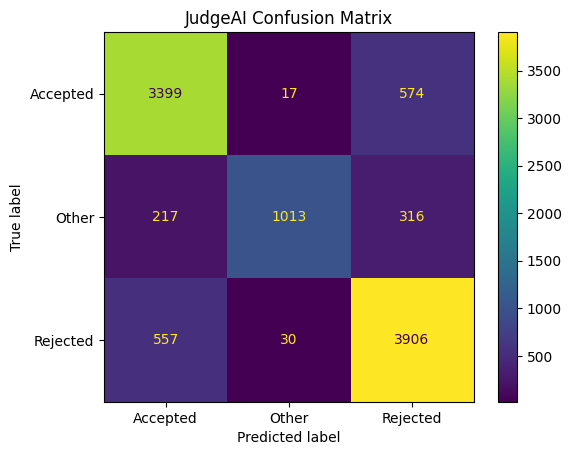

In [38]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay



display = ConfusionMatrixDisplay(

    confusion_matrix=confusion_matrix_result,

    display_labels=random_forest_model.classes_

)

display.plot()

plt.title(

    "JudgeAI Confusion Matrix"

)

plt.show()

# Precision, Recall and F1 Score

Objective:

Evaluate the performance of the Random Forest model using additional metrics.

Metrics:

Precision

Recall

F1 Score

In [39]:
from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score

)

# Calculate Precision

Precision measures how many predicted values are actually correct.

In [40]:
precision = precision_score(

    y_test,

    random_forest_prediction,

    average="weighted"

)

print(

    f"Precision : {precision:.4f}"

)

recall = recall_score(

    y_test,

    random_forest_prediction,

    average="weighted"

)

print(

    f"Recall : {recall:.4f}"

)

f1 = f1_score(

    y_test,

    random_forest_prediction,

    average="weighted"

)

print(

    f"F1 Score : {f1:.4f}"

)

Precision : 0.8362
Recall : 0.8294
F1 Score : 0.8279


In [41]:
import joblib

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print(
    "TF-IDF Saved Successfully ✅"
)

TF-IDF Saved Successfully ✅


In [42]:
judgment_info.sample(5)[["judgement", "label"]]

,judgement,label
42424,state 1 sales tax-a cash refund will be all...,Rejected
15031,14-taxation on income investigation commissio...,Other
5332,"headnote on september 3, 1957 the chief commis...",Rejected
27414,leave granted in s.l.p c number 883 of 2000....,Rejected
31421,vs. respondent m. abdul khadir date of judgmen...,Accepted


In [43]:
print(judgment_info["judgement"].iloc[0])

thus spake benjamin franklin in his letter of november 13, 1789 to jean baptiste leroy.
to tax the dead is a contradiction in terms.
tax laws are made by the living to tax the living.
what survives the dead person is what is left behind in the form of such persons property.
this appeal raises questions as to whether the dead persons property, in the form of his or her estate, can be taxed without the necessary machinery provisions in a tax statute.
the precise question that arises in the present case is whether an assessment proceeding under the central excises and salt act, 1944, can continue against the legal representatives estate of a sole proprietor manufacturer after he is dead.
the facts of the case are as follows.
2. one shri george varghese was the sole proprietor of kerala tyre and rubber company limited.
by october 1985, this proprietary concern had stopped manufacture and production of tread rubber.
by a show cause notice dated 12.6.1987, for the period january 1983 to dece

In [44]:
print(judgment_info["judgement"].iloc[10])

 prove that the wall in dispute and the khaprail existed for the last more than 12 years before the suit.
the civil judge further held on surmises as may be that the wall and khaprail have not been raised on may 1961 as is the plaintiffs case, but they are recent constructions.
this decision of the lower appellate court is wholly incorrect being contrary to the evidence on record.
1037a-b judgment civil appellate jurisdiction civil appeal number 755 of from the judgment and order dated 21.12.1970 of the allahabad high court in second appeal number 2757 of 1963.
d.p. singh, r.p. singh and d.s. mehra for the appellant.
l.p. vats and s.p.
panday for the respondent.
the judgment of the court was delivered by b.c. ray, j. this appeal by special leave is against the judgment and decree dated 21st december, 1970 of the allahabad high court in second appeal number 2757 of 1963 allowing the appeal on setting aside the judgment and decree of the court of appeal below and dismissing the plaintiff

In [45]:
print(judgment_info["judgement"].iloc[25])

date of judgment 28/02/1966 bench hidayatullah, m. bench hidayatullah, m. gajendragadkar, p.b.  cj  wanchoo, k.n. shah, j.c. sikri, s.m. citation 1967 air 85 1966 scr  3  672 act the representation of the people act  43 of 1951 , s. 36 4  and conduct of election rules, 1961, r. 4-filling up nomination paper with one reserved symbol and leaving the rest blank-if a defect of substantial character headnote the nomination form prescribed for election to the state assembly had a blank space, where a candidate could show three symbols in order of preference as his symbol.
one of the candidates for -election showed only one symbol which was reserved for a political party, and left blank the rest of the space.
the returning officer rejected the nomination paper holding that the defects was of a substantial character.
alleging that the rejection was improper two voters filed an election petition challenging the lection of the appellant who was successful at the ensuing election the tribunal dis